In [23]:
import pandas as pd
import numpy as np

import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt

from outlier_util import remove_outliers_iqr


In [24]:
# Load the data from the CSV file

df = pd.read_csv("../data/train_data-cleaned.csv")
df = remove_outliers_iqr(df, columns=['price', 'livingArea'], multiplier=1.5, min_thresholds={'livingArea' : 25})

df_test = pd.read_csv("../data/test_data-cleaned.csv")
df_test = remove_outliers_iqr(df_test, columns=['price', 'livingArea'], multiplier=1.5, min_thresholds={'livingArea' : 25})

# Display the first few rows to verify the data was loaded correctly
df.head(5)

,Unnamed: 0,propertyId,postalCode,typeOfProperty,subtypeOfProperty,price,typeOfSale,numberOfRooms,livingArea,equippedKitchen,...,hasThermicPanels,hasCollectiveWaterHeater,hasDoubleGlazing,epcScore,primaryEnergyConsumptionPerSqm,renovationObligation,cadastralIncome,parkingCountIndoor,parkingCountOutdoor,parkingCountClosedBox
0,57065,20628133,8670,0,14,629000,0,9,221,-1,...,0,0,1,4,366,-1,1,1,-1,-1
1,8659,20174756,1420,1,1,267500,0,5,75,1,...,0,-1,0,3,228,-1,1214,1,1,-1
2,56658,10752051,8660,1,1,339500,0,4,96,-1,...,0,-1,1,1,-1,0,-1,-1,-1,-1
3,11053,20656164,3060,0,0,595000,0,10,210,3,...,-1,-1,1,2,125,0,1395,1,-1,-1
4,8289,20638235,1341,0,0,380000,0,8,115,2,...,-1,-1,1,-1,577,-1,1581,1,1,-1


Prepare for regression + Standardize scales

In [25]:
price_correlations = df.corr()['price'].abs().sort_values(ascending=False)
features = price_correlations.index.tolist()[1:]

target = 'price'

x_train = df[features]
y_train = df[target]

# Split the dataset
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_test = df_test[features]
y_test = df_test[target]

---
## Option 1: Linear Regression Coefficients (for linear relationships)

<Axes: title={'center': 'Linear Regression Feature Importance'}>

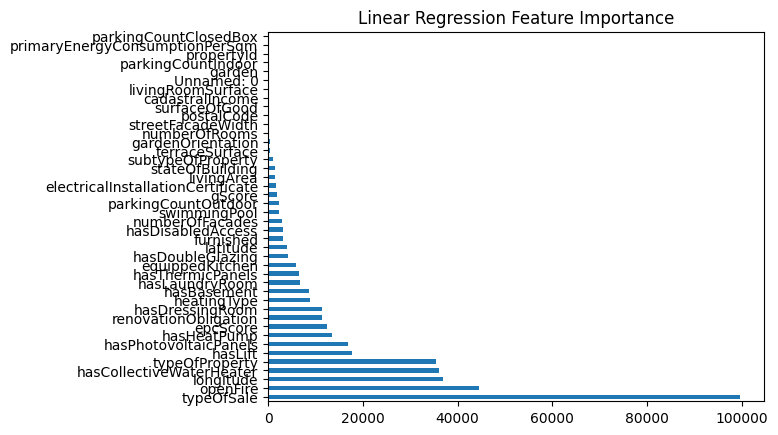

In [26]:
lr = LinearRegression()
lr.fit(x_train, y_train)

# Get importance from coefficients (absolute values give relative importance)
importance = pd.Series(np.abs(lr.coef_), index=features)
importance.sort_values(ascending=False).plot(kind='barh', title='Linear Regression Feature Importance')

## Evaluate Model

In [27]:
y_pred = lr.predict(x_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100, "%")
print("MAE:", np.mean(np.abs(y_test - y_pred)))

RMSE: 120501.05689171125
R² Score: 0.4892548649415446
MAPE: inf %
MAE: 87364.48565389185


---

## Option 2: XGBoost
XGBoost (eXtreme Gradient Boosting) is another powerful ensemble learning technique that often outperforms both linear regression and random forest models. It uses gradient boosting with regularization to reduce overfitting and improve performance.

Key advantages of XGBoost:
- High performance and efficient computation
- Regularization to prevent overfitting
- Handles missing values automatically
- Supports parallel processing
- Offers built-in cross-validation

For our housing price prediction task, XGBoost can capture complex non-linear relationships while maintaining good generalization performance.

<Axes: title={'center': 'XGBoost Feature Importance'}>

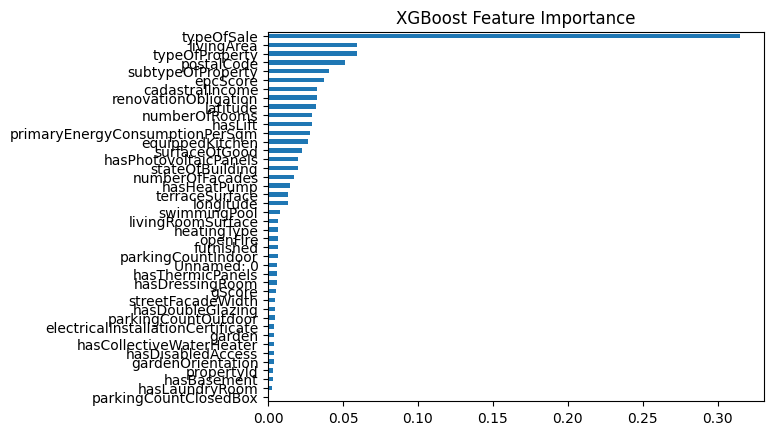

In [28]:

# Initialize XGBoost model with good default parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.6,
    objective='reg:squarederror',
    random_state=42
)

# # Finetuning with GridSearchCV,
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0],
#     'min_child_weight': [1, 3, 5]
# }
# grid_search = GridSearchCV(
#     estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )
# grid_search.fit(x_train, y_train)
# best_params = grid_search.best_params_
# print(f"Best parameters: {best_params}")
# xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)

# Train the model
xgb_model.fit(x_train, y_train)

# Get feature importance
importance = pd.Series(xgb_model.feature_importances_, index=features)
importance.sort_values(ascending=True).plot(
    kind='barh', 
    title='XGBoost Feature Importance'
)

### Evaluate Model

In [29]:
# Make predictions
y_pred = xgb_model.predict(x_test)

# Evaluate the model
print("XGBoost Performance Metrics:")
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred) * 100, "%")
print("MAE:", mean_absolute_error(y_test, y_pred))



XGBoost Performance Metrics:
RMSE: 67681.7421875
R² Score: 0.8388740420341492
MAPE: 5.974942723038249e+19 %
MAE: 47035.4453125
